#Uso de modelos que ayudan a predecir la probabilidad de desarrollar una enfermedad en una población o individuo en base a antecedentes médicos(Necropatía diabética)

In [ ]:
import pandas as pd
nefro = pd.read_csv("Data_nefro.csv", sep=";")
nefro

,N,SEXO,EDAD,IMC,TIPO,DURATION,FBS,A1C,LDL,HDL,TG,TRAT,NEFRO,SYST,DIAST
0,1,Male,65,25.0,2,20.0,129,7.10,100,40,200,Oral,1,130,80
1,2,Male,42,27.0,2,3.0,210,8.90,125,38,151,Oral,0,140,90
2,3,Female,31,21.0,1,11.0,164,7.70,147,35,217,Ins,0,145,80
3,4,Male,70,32.0,2,29.0,208,9.30,119,36,168,Ins,1,160,100
4,5,Female,54,34.0,2,6.0,183,9.80,196,32,197,Oral,1,155,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Male,52,34.5,2,3.0,138,7.33,113,33,217,Oral,0,115,75
129,130,Female,56,22.0,2,3.0,156,7.16,80,43,179,Oral,0,130,90
130,131,Male,65,24.0,2,3.0,300,9.67,58,20,96,Ins,1,120,80
131,132,Male,56,33.0,2,5.0,213,8.74,107,34,756,Both,1,155,110


In [ ]:
import pandas as pd
import gdown


file_id = "1ap17azFMxW1SWWCQIITI8QBI9ElwkqeS"
url = f"https://drive.google.com/uc?id={file_id}"


output = "Data_nefro.csv"
gdown.download(url, output, quiet=False)


nefro = pd.read_csv(output, sep=";")
nefro


Downloading...
From: https://drive.google.com/uc?id=1ap17azFMxW1SWWCQIITI8QBI9ElwkqeS
To: /content/Data_nefro.csv
100%|██████████| 7.25k/7.25k [00:00<00:00, 10.1MB/s]


,N,SEXO,EDAD,IMC,TIPO,DURATION,FBS,A1C,LDL,HDL,TG,TRAT,NEFRO,SYST,DIAST
0,1,Male,65,25.0,2,20.0,129,7.10,100,40,200,Oral,1,130,80
1,2,Male,42,27.0,2,3.0,210,8.90,125,38,151,Oral,0,140,90
2,3,Female,31,21.0,1,11.0,164,7.70,147,35,217,Ins,0,145,80
3,4,Male,70,32.0,2,29.0,208,9.30,119,36,168,Ins,1,160,100
4,5,Female,54,34.0,2,6.0,183,9.80,196,32,197,Oral,1,155,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Male,52,34.5,2,3.0,138,7.33,113,33,217,Oral,0,115,75
129,130,Female,56,22.0,2,3.0,156,7.16,80,43,179,Oral,0,130,90
130,131,Male,65,24.0,2,3.0,300,9.67,58,20,96,Ins,1,120,80
131,132,Male,56,33.0,2,5.0,213,8.74,107,34,756,Both,1,155,110


In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder= LabelEncoder()
nefro= pd.get_dummies(nefro, columns=["TRAT"])
nefro.SEXO= label_encoder.fit_transform(nefro.SEXO)
nefro

,N,SEXO,EDAD,IMC,TIPO,DURATION,FBS,A1C,LDL,HDL,TG,NEFRO,SYST,DIAST,TRAT_Both,TRAT_Ins,TRAT_Oral
0,1,1,65,25.0,2,20.0,129,7.10,100,40,200,1,130,80,False,False,True
1,2,1,42,27.0,2,3.0,210,8.90,125,38,151,0,140,90,False,False,True
2,3,0,31,21.0,1,11.0,164,7.70,147,35,217,0,145,80,False,True,False
3,4,1,70,32.0,2,29.0,208,9.30,119,36,168,1,160,100,False,True,False
4,5,0,54,34.0,2,6.0,183,9.80,196,32,197,1,155,95,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,1,52,34.5,2,3.0,138,7.33,113,33,217,0,115,75,False,False,True
129,130,0,56,22.0,2,3.0,156,7.16,80,43,179,0,130,90,False,False,True
130,131,1,65,24.0,2,3.0,300,9.67,58,20,96,1,120,80,False,True,False
131,132,1,56,33.0,2,5.0,213,8.74,107,34,756,1,155,110,True,False,False


In [ ]:
x=nefro.drop(["N", "NEFRO"], axis=1)
y=nefro["NEFRO"]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
scaler= scaler.fit(x)
x= scaler.transform(x)
x

array([[ 1.19087439,  0.85268294, -0.83428582, ..., -0.57445626,
        -0.50469494,  0.90659683],
       [ 1.19087439, -0.9880772 , -0.43064808, ..., -0.57445626,
        -0.50469494,  0.90659683],
       [-0.83971912, -1.86844075, -1.64156129, ..., -0.57445626,
         1.98139494, -1.10302614],
       ...,
       [ 1.19087439,  0.85268294, -1.03610469, ..., -0.57445626,
         1.98139494, -1.10302614],
       [ 1.19087439,  0.1323855 ,  0.78026513, ...,  1.74077656,
        -0.50469494, -1.10302614],
       [ 1.19087439, -0.5078789 ,  0.37662739, ..., -0.57445626,
        -0.50469494,  0.90659683]])

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


In [ ]:
#MODELO ACTUAL
# from keras.models import Sequential
# from keras.layers import Dense
# from keras.callbacks import EarlyStopping
# model= Sequential()
# model.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))
# model.add(Dense(128, activation="relu"))
# model.add(Dense(256, activation="relu"))
# model.add(Dense(128, activation="relu"))
# model.add(Dense(64, activation="relu"))
# model.add(Dense(32, activation="relu"))
# model.add(Dense(1, activation="sigmoid"))

# model.compile(loss="binary_crossentropy")

# stop= EarlyStopping(monitor="val_loss", patience=3)
# model.fit(x_train, y_train, epochs=100, validation_split=0.2, callbacks=[stop])

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.regularizers import l2
from keras.layers import LeakyReLU

# Definición del modelo mejorado
model = Sequential()
model.add(Dense(128, input_shape=(x_train.shape[1],), kernel_regularizer=l2(0.001)))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.3))

model.add(Dense(128, kernel_regularizer=l2(0.001)))
model.add(LeakyReLU(alpha=0.1))
model.add(Dropout(0.4))

model.add(Dense(64, kernel_regularizer=l2(0.001)))
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(32, kernel_regularizer=l2(0.001)))
model.add(LeakyReLU(alpha=0.1))

model.add(Dense(1, activation="sigmoid"))

# Compilación con optimización de tasa de aprendizaje
model.compile(optimizer=Adam(learning_rate=0.0005),
              loss="binary_crossentropy",
              metrics=['accuracy', 'AUC'])

# EarlyStopping basado en AUC
stop = EarlyStopping(monitor="val_AUC", patience=7, restore_best_weights=True, mode='max')

# Entrenamiento del modelo
model.fit(x_train, y_train, epochs=200, validation_split=0.2, callbacks=[stop], batch_size=64)

# Evaluación del modelo
loss, accuracy, auc = model.evaluate(x_test, y_test)
print(f'Accuracy: {accuracy:.4f}, AUC: {auc:.4f}')


Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 464ms/step - AUC: 0.4916 - accuracy: 0.4501 - loss: 0.9890 - val_AUC: 0.5333 - val_accuracy: 0.4545 - val_loss: 0.9808
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - AUC: 0.5115 - accuracy: 0.5685 - loss: 0.9807 - val_AUC: 0.7000 - val_accuracy: 0.5455 - val_loss: 0.9659
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - AUC: 0.7130 - accuracy: 0.7054 - loss: 0.9338 - val_AUC: 0.7542 - val_accuracy: 0.5455 - val_loss: 0.9508
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - AUC: 0.7333 - accuracy: 0.6947 - loss: 0.9324 - val_AUC: 0.8000 - val_accuracy: 0.7273 - val_loss: 0.9354
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - AUC: 0.8384 - accuracy: 0.8157 - loss: 0.8969 - val_AUC: 0.8208 - val_accuracy: 0.7727 - val_loss: 0.9207
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - AUC: 0.7494 - accuracy: 0.6895 - loss: 0.9036 - val_AUC: 0.8292 - val_accuracy: 0.7727 - val_loss: 0.9058
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - AUC: 0.837

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


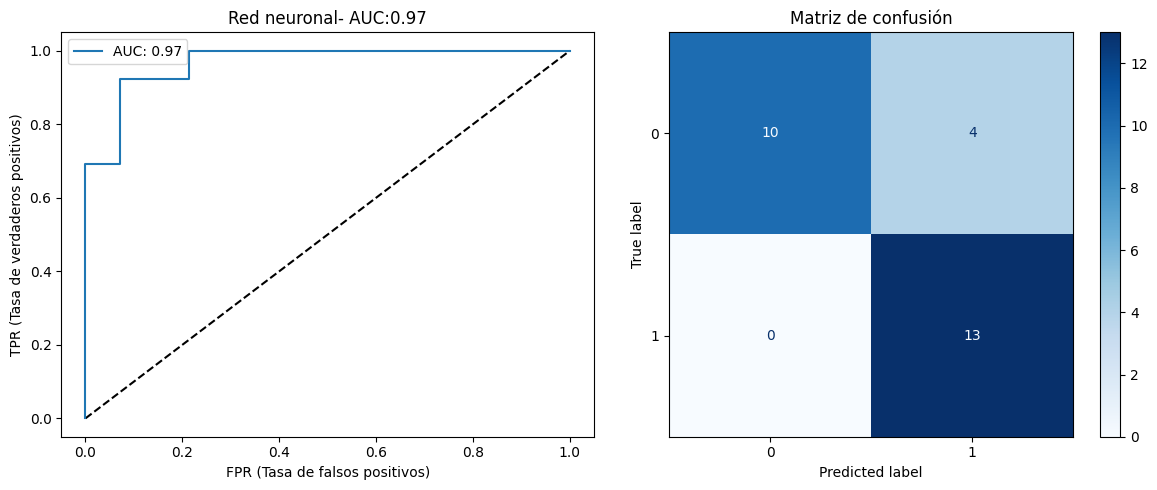

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predicciones del modelo
y_pred = model.predict(x_test).ravel()
y_pred_class = (y_pred >= 0.5).astype(int)  # Convertir probabilidades en clases binarias

# Calcular curva ROC y AUC
fpr, tpr, _ = roc_curve(y_test, y_pred)
area = roc_auc_score(y_test, y_pred)

# Crear figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica 1: Curva ROC
axes[0].plot([0,1], [0,1], "k--")
axes[0].plot(fpr, tpr, label=f"AUC: {area:.2f}")
axes[0].set_title("Red neuronal- AUC:"+str(round(area,2)))
axes[0].set_xlabel("FPR (Tasa de falsos positivos)")
axes[0].set_ylabel("TPR (Tasa de verdaderos positivos)")
axes[0].legend()

# Gráfica 2: Matriz de confusión
cm = confusion_matrix(y_test, y_pred_class)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Matriz de confusión")

plt.tight_layout()
plt.show()


Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - AUC: 0.8026 - accuracy: 0.7158 - loss: 0.9029 - val_AUC: 0.8417 - val_accuracy: 0.8182 - val_loss: 0.9050
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - AUC: 0.8587 - accuracy: 0.7607 - loss: 0.8876 - val_AUC: 0.8375 - val_accuracy: 0.7727 - val_loss: 0.8959
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - AUC: 0.8821 - accuracy: 0.8053 - loss: 0.8539 - val_AUC: 0.8375 - val_accuracy: 0.7727 - val_loss: 0.8870
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - AUC: 0.8868 - accuracy: 0.8341 - loss: 0.8260 - val_AUC: 0.8333 - val_accuracy: 0.7727 - val_loss: 0.8792
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - AUC: 0.8843 - accuracy: 0.7894 - loss: 0.8390 - val_AUC: 0.8292 - val_accuracy: 0.7727 - val_loss: 0.8712
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - AUC: 0.8988 - accuracy: 0.8001 - loss: 0.7961 - val_AUC: 0.8250 - val_accuracy: 0.7727 - val_loss: 0.8637
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step -

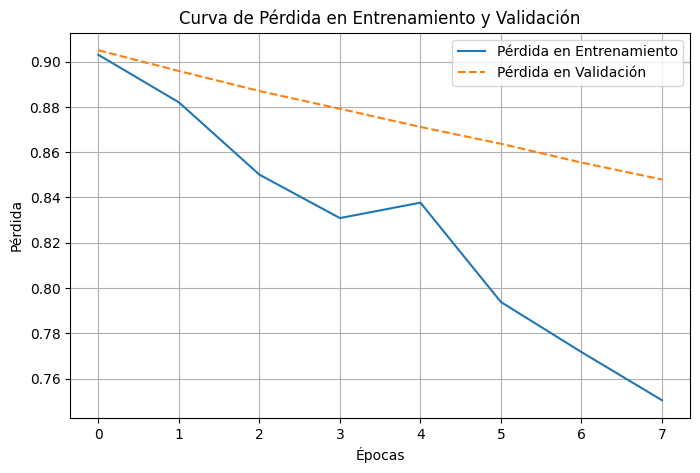

In [ ]:
import matplotlib.pyplot as plt

# Entrenar el modelo y guardar el historial
history = model.fit(x_train, y_train, epochs=200, validation_split=0.2,
                    callbacks=[stop], batch_size=64, verbose=1)

# Extraer las pérdidas
loss_train = history.history['loss']
loss_val = history.history['val_loss']

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.plot(loss_train, label='Pérdida en Entrenamiento')
plt.plot(loss_val, label='Pérdida en Validación', linestyle="--")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Curva de Pérdida en Entrenamiento y Validación")
plt.legend()
plt.grid()
plt.show()


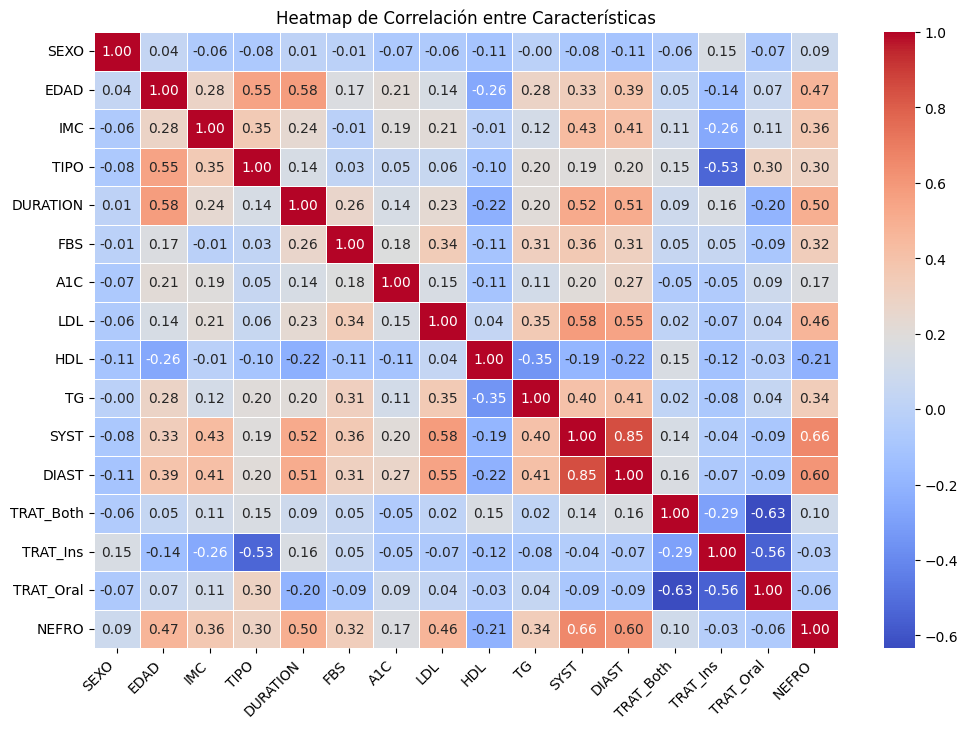

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Crear un DataFrame con los datos normalizados
df_corr = pd.DataFrame(x, columns=nefro.drop(["N", "NEFRO"], axis=1).columns)
df_corr["NEFRO"] = y  # Agregar la variable objetivo al DataFrame

# Calcular la matriz de correlación
correlation_matrix = df_corr.corr()

# Crear el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Personalización del gráfico
plt.title("Heatmap de Correlación entre Características")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()


In [ ]:
nuevo_pacientes= pd.DataFrame({
    "SEXO": [1,1],
    "EDAD": [40,70],
    "IMC" : [22,30],
    "TIPO": [2,2],
    "DURATION": [4,5],
    "FBS": [90,130],
    "A1C": [5,5],
    "LDL": [120,150],
    "HDL": [50,50],
    "TG": [180,210],
    "SYST": [140,140],
    "DIAST": [90,90],
    "TRAT_Both": [0,1],
    "TRAT_Ins": [0,1],
    "TRAT_Oral": [1,1],
})

nuevo_pacientes= scaler.transform(nuevo_pacientes)
nuevo_pacientes

pred= model.predict(nuevo_pacientes)
print("Probabilidad de enfermedad, paciente 1:", round(pred[0][0],2)*100, "%")
print("Probabilidad de enfermedad, paciente 2:", round(pred[1][0],2)*100, "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Probabilidad de enfermedad, paciente 1: 10.000000149011612 %
Probabilidad de enfermedad, paciente 2: 49.000000953674316 %
